## Loading data

In [47]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [48]:
from skfp.datasets.moleculenet import load_tox21

df = load_tox21(as_frame=True)
print(df.head())

                                              SMILES  NR-AR  NR-AR-LBD  \
0                       CCOc1ccc2nc(S(N)(=O)=O)sc2c1    0.0        0.0   
1                          CCN1C(=O)NC(c2ccccc2)C1=O    0.0        0.0   
2  CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...    NaN        NaN   
3                    CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C    0.0        0.0   
4                          CC(O)(P(=O)(O)O)P(=O)(O)O    0.0        0.0   

   NR-AhR  NR-Aromatase  NR-ER  NR-ER-LBD  NR-PPAR-gamma  SR-ARE  SR-ATAD5  \
0     1.0           NaN    NaN        0.0            0.0     1.0       0.0   
1     0.0           0.0    0.0        0.0            0.0     NaN       0.0   
2     NaN           NaN    NaN        NaN            NaN     0.0       NaN   
3     0.0           0.0    0.0        0.0            0.0     NaN       0.0   
4     0.0           0.0    0.0        0.0            0.0     0.0       0.0   

   SR-HSE  SR-MMP  SR-p53  
0     0.0     0.0     0.0  
1     NaN     0.0     0.0  
2 

In [49]:
import pandas as pd

def class_percentages(df):
    label_cols = df.columns[1:]
    percentages = {}

    for col in label_cols:
        total = len(df)
        zero_count = (df[col] == 0).sum()
        one_count = (df[col] == 1).sum()
        nan_count = df[col].isna().sum()
        
        percentages[col] = {
            "0": (zero_count / total),
            "1": (one_count / total),
            "NaN": (nan_count / total)
        }

    return pd.DataFrame(percentages).T

percentages_df = class_percentages(df)
print(percentages_df)


                      0         1       NaN
NR-AR          0.888265  0.039459  0.072277
NR-AR-LBD      0.832716  0.030264  0.137020
NR-AhR         0.738220  0.098072  0.163708
NR-Aromatase   0.705019  0.038309  0.256672
NR-ER          0.689567  0.101264  0.209169
NR-ER-LBD      0.843443  0.044694  0.111863
NR-PPAR-gamma  0.799898  0.023752  0.176350
SR-ARE         0.624441  0.120291  0.255268
SR-ATAD5       0.869365  0.033712  0.096922
SR-HSE         0.778317  0.047504  0.174180
SR-MMP         0.624697  0.117226  0.258077
SR-p53         0.811008  0.054016  0.134976


In [50]:
print("Percentage of NaNs in each label")
print(df.drop(columns=['SMILES']).isna().mean() * 100.0)

Percentage of NaNs in each label
NR-AR             7.227685
NR-AR-LBD        13.701954
NR-AhR           16.370834
NR-Aromatase     25.667220
NR-ER            20.916869
NR-ER-LBD        11.186311
NR-PPAR-gamma    17.635040
SR-ARE           25.526753
SR-ATAD5          9.692249
SR-HSE           17.417954
SR-MMP           25.807687
SR-p53           13.497638
dtype: float64


In [51]:
df = df.dropna().reset_index(drop=True)

smiles = df['SMILES']
toxicity_labels = df.drop(columns=['SMILES'])
print(toxicity_labels)


      NR-AR  NR-AR-LBD  NR-AhR  NR-Aromatase  NR-ER  NR-ER-LBD  NR-PPAR-gamma  \
0       0.0        0.0     0.0           0.0    0.0        0.0            0.0   
1       0.0        0.0     0.0           0.0    0.0        0.0            0.0   
2       0.0        0.0     0.0           0.0    0.0        0.0            0.0   
3       0.0        0.0     0.0           0.0    0.0        0.0            0.0   
4       0.0        0.0     0.0           0.0    0.0        0.0            1.0   
...     ...        ...     ...           ...    ...        ...            ...   
3074    0.0        0.0     0.0           0.0    1.0        0.0            0.0   
3075    0.0        0.0     0.0           0.0    0.0        0.0            0.0   
3076    0.0        0.0     0.0           0.0    0.0        0.0            0.0   
3077    0.0        0.0     0.0           0.0    0.0        0.0            0.0   
3078    1.0        1.0     0.0           0.0    1.0        1.0            0.0   

      SR-ARE  SR-ATAD5  SR-

In [52]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(smiles, toxicity_labels, test_size=0.2)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 2463 samples
Testing set size: 616 samples


## Converting SMILES to graph adj. list representation

In [53]:
from rdkit import Chem
import torch

def smile_to_graph(smile):
    mol = Chem.MolFromSmiles(smile)
    
    node_features = []
    for atom in mol.GetAtoms():
        node_features.append([
            atom.GetAtomicNum(), 
            atom.GetFormalCharge(), 
            atom.GetDegree(), 
            atom.GetTotalValence(),
            int(atom.GetHybridization()),  
            int(atom.GetIsAromatic()),  
            atom.GetTotalNumHs(),  
            int(atom.HasProp('_ChiralityPossible'))  
        ])

    node_features = torch.tensor(node_features, dtype=torch.float)
    
    edge_index = []
    edge_attr = []
    
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        bond_type = bond.GetBondTypeAsDouble()
        aromatic = 1.0 if bond.GetIsAromatic() else 0.0
        conjugated = 1.0 if bond.GetIsConjugated() else 0.0
        in_ring = 1.0 if bond.IsInRing() else 0.0
        stereo = int(bond.GetStereo())

        edge_index.append([i, j])
        edge_index.append([j, i])

        edge_attr.append([bond_type, aromatic, conjugated, in_ring, stereo])
        edge_attr.append([bond_type, aromatic, conjugated, in_ring, stereo])
    
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)
    
    return node_features, edge_index, edge_attr

# Example usage with the first SMILES in the dataset
node_features, edge_index, edge_attr = smile_to_graph(smiles[1])

print("Node features:", node_features)
print("Edge index:", edge_index)
print("Edge attributes:", edge_attr)


Node features: tensor([[ 8.,  0.,  1.,  2.,  3.,  0.,  0.,  0.],
        [16.,  0.,  4.,  6.,  4.,  0.,  0.,  0.],
        [ 8.,  0.,  1.,  2.,  3.,  0.,  0.,  0.],
        [17.,  0.,  1.,  1.,  4.,  0.,  0.,  0.],
        [ 6.,  0.,  3.,  4.,  3.,  1.,  0.,  0.],
        [ 6.,  0.,  2.,  4.,  3.,  1.,  1.,  0.],
        [ 6.,  0.,  2.,  4.,  3.,  1.,  1.,  0.],
        [ 6.,  0.,  2.,  4.,  3.,  1.,  1.,  0.],
        [ 6.,  0.,  2.,  4.,  3.,  1.,  1.,  0.],
        [ 6.,  0.,  2.,  4.,  3.,  1.,  1.,  0.]])
Edge index: tensor([[0, 1, 1, 2, 1, 3, 1, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 4],
        [1, 0, 2, 1, 3, 1, 4, 1, 5, 4, 6, 5, 7, 6, 8, 7, 9, 8, 4, 9]])
Edge attributes: tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [2.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [2.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [2.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [1.000

In [54]:
from torch_geometric.data import Data

def prepare_graph_data(smiles, toxicity_labels):
    graph_data = []
    
    for i, smi in enumerate(smiles):
        node_features, edge_index, edge_attr = smile_to_graph(smi)
        labels = toxicity_labels.iloc[i].values
        
        # PyTorch Geometric data object
        data = Data(x=node_features, edge_index=edge_index, edge_attr=edge_attr, y=torch.tensor(labels, dtype=torch.float))
        graph_data.append(data)
    
    return graph_data

## GINE Model

In [55]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric import nn as pyg_nn
from torch_geometric.nn import GINEConv
from torch_geometric.loader import DataLoader

class GINEToxicityModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, edge_dim):
        super(GINEToxicityModel, self).__init__()
        
        self.conv1 = GINEConv(
            nn=nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim)),
            edge_dim=edge_dim
        )
        
        self.conv2 = GINEConv(
            nn=nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim)),
            edge_dim=edge_dim
        )
        
        self.fc = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        x = self.conv1(x, edge_index, edge_attr)
        x = self.conv2(x, edge_index, edge_attr)
        
        # Graph-level pooling
        x = pyg_nn.global_mean_pool(x, data.batch)
        x = self.fc(x)
        return x


In [56]:
graph_data = prepare_graph_data(X_train, y_train)
train_loader = DataLoader(graph_data, batch_size=32, shuffle=True)
model = GINEToxicityModel(input_dim=8, hidden_dim=64, output_dim=toxicity_labels.shape[1], edge_dim=5)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

loss_history = []

for epoch in range(100):
    model.train()
    print(f"Epoch {epoch+1}...", end="")
    for data in train_loader:
        optimizer.zero_grad()
        data.y = data.y.view(-1, toxicity_labels.shape[1])
        output = model(data)
        loss = criterion(output, data.y)
        loss.backward()
        optimizer.step()

    loss_history.append(loss.item())
    print(f" Loss: {loss.item():0.04f}")

Epoch 1... Loss: 0.1850
Epoch 2... Loss: 0.1888
Epoch 3... Loss: 0.1214
Epoch 4... Loss: 0.0873
Epoch 5... Loss: 0.1601
Epoch 6... Loss: 0.0627
Epoch 7... Loss: 0.1120
Epoch 8... Loss: 0.1642
Epoch 9... Loss: 0.1291
Epoch 10... Loss: 0.0560
Epoch 11... Loss: 0.0636
Epoch 12... Loss: 0.1547
Epoch 13... Loss: 0.2183
Epoch 14... Loss: 0.1218
Epoch 15... Loss: 0.1134
Epoch 16... Loss: 0.1262
Epoch 17... Loss: 0.1194
Epoch 18... Loss: 0.1124
Epoch 19... Loss: 0.0972
Epoch 20... Loss: 0.0833
Epoch 21... Loss: 0.0933
Epoch 22... Loss: 0.0657
Epoch 23... Loss: 0.1163
Epoch 24... Loss: 0.0446
Epoch 25... Loss: 0.0917
Epoch 26... Loss: 0.1122
Epoch 27... Loss: 0.1208
Epoch 28... Loss: 0.1605
Epoch 29... Loss: 0.1140
Epoch 30... Loss: 0.1763
Epoch 31... Loss: 0.0592
Epoch 32... Loss: 0.0786
Epoch 33... Loss: 0.1295
Epoch 34... Loss: 0.1527
Epoch 35... Loss: 0.1395
Epoch 36... Loss: 0.1229
Epoch 37... Loss: 0.0360
Epoch 38... Loss: 0.0854
Epoch 39... Loss: 0.1324
Epoch 40... Loss: 0.1805
Epoch 41.

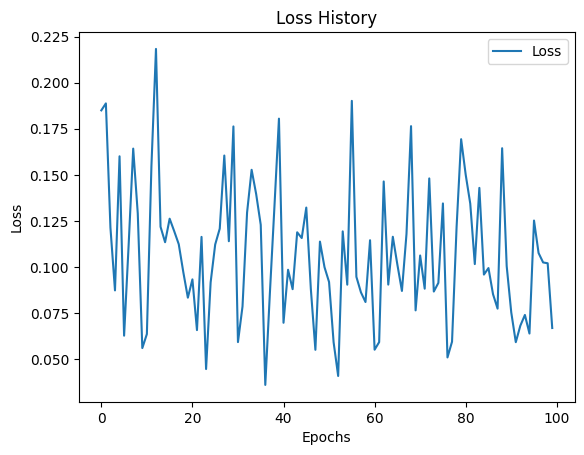

In [57]:
import matplotlib.pyplot as plt

plt.plot(loss_history, label="Loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss History')
plt.legend()
plt.show()